# CVE 严重等级模型评估可视化

本 Notebook 用于生成四类模型评估图：测试准确率比较、测试 F1 值比较、交叉验证平均值比较、训练/测试准确率比较。

运行方式：在 VS Code 中从上到下依次运行每个代码单元格。

In [ ]:
from pathlib import Path
import os
import json

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [ ]:
# 固定工作目录，保证 data/ 和 docs/ 路径可以正确找到。
project_root = Path(r"C:\Users\33431\Desktop\asset_discovery")
os.chdir(project_root)

samples_path = Path("data/cve_samples.csv")
eval_dir = Path("docs/ml_eval")
eval_dir.mkdir(parents=True, exist_ok=True)

label_order = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]

# 调试时建议使用 20000，速度较快；论文正式结果可改为 None 使用完整数据集。
sample_limit = 20000

print("当前工作目录：", Path.cwd())
print("训练数据文件：", samples_path.resolve())

In [ ]:
df = pd.read_csv(samples_path)

if "training_text" not in df.columns:
    df["training_text"] = df["description"]

df["training_text"] = df["training_text"].fillna(df.get("description", ""))
df = df.dropna(subset=["training_text", "severity"])
df["severity"] = df["severity"].astype(str).str.upper().str.strip()
df = df[df["severity"].isin(label_order)]

if sample_limit is not None:
    per_label = max(1, sample_limit // len(label_order))
    df = (
        df.groupby("severity", group_keys=False)
        .apply(lambda item: item.sample(min(len(item), per_label), random_state=42))
        .reset_index(drop=True)
    )

print("样本总数：", len(df))
print(df["severity"].value_counts())

In [ ]:
train_x, test_x, train_y, test_y = train_test_split(
    df["training_text"],
    df["severity"],
    test_size=0.2,
    random_state=42,
    stratify=df["severity"],
)

print("训练集数量：", len(train_x))
print("测试集数量：", len(test_x))

In [ ]:
def build_pipeline(classifier):
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    stop_words="english",
                    ngram_range=(1, 3),
                    sublinear_tf=True,
                    min_df=2,
                    max_features=50000,
                ),
            ),
            ("classifier", classifier),
        ]
    )


model_defs = {
    "Logistic Regression": LogisticRegression(
        max_iter=1200,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42,
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=45,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=1,
        random_state=42,
    ),
}

In [ ]:
rows = []
trained_models = {}

for model_name, classifier in model_defs.items():
    print(f"正在训练：{model_name}")
    model = build_pipeline(classifier)
    model.fit(train_x, train_y)

    train_pred = model.predict(train_x)
    test_pred = model.predict(test_x)

    row = {
        "model": model_name,
        "train_accuracy": accuracy_score(train_y, train_pred),
        "test_accuracy": accuracy_score(test_y, test_pred),
        "test_macro_f1": f1_score(test_y, test_pred, labels=label_order, average="macro", zero_division=0),
        "test_weighted_f1": f1_score(test_y, test_pred, labels=label_order, average="weighted", zero_division=0),
    }

    rows.append(row)
    trained_models[model_name] = model

metrics_df = pd.DataFrame(rows)
metrics_df

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []

for model_name, classifier in model_defs.items():
    print(f"正在进行交叉验证：{model_name}")
    model = build_pipeline(classifier)
    scores = cross_val_score(
        model,
        df["training_text"],
        df["severity"],
        cv=cv,
        scoring="accuracy",
        n_jobs=1,
    )
    cv_rows.append(
        {
            "model": model_name,
            "cv_accuracy_mean": scores.mean(),
            "cv_accuracy_std": scores.std(),
        }
    )

cv_df = pd.DataFrame(cv_rows)
metrics_df = metrics_df.merge(cv_df, on="model")

metrics_df.to_csv(eval_dir / "model_visualization_metrics.csv", index=False, encoding="utf-8-sig")
(eval_dir / "model_visualization_metrics.json").write_text(
    json.dumps(metrics_df.to_dict(orient="records"), ensure_ascii=False, indent=2),
    encoding="utf-8",
)

metrics_df

In [ ]:
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.facecolor"] = "#ffffff"
plt.rcParams["axes.facecolor"] = "#fbfbfa"
plt.rcParams["axes.edgecolor"] = "#c9c2b8"
plt.rcParams["axes.labelcolor"] = "#2f3437"
plt.rcParams["xtick.color"] = "#4b5563"
plt.rcParams["ytick.color"] = "#4b5563"

# 低饱和论文配色，避免过亮的默认红绿蓝。
model_palette = ["#4f6d7a", "#6f7d5c", "#8a6f5a"]
f1_palette = ["#6f6586", "#9a7b5f"]
accuracy_pair_palette = ["#526a7a", "#9b7f65"]


def save_bar_chart(title, data, y_label, output_name, ylim=(0, 1.05)):
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(data["model"], data["value"], color=data["color"])

    ax.set_title(title, fontsize=15)
    ax.set_ylabel(y_label)
    ax.set_ylim(*ylim)
    ax.grid(axis="y", linestyle="--", alpha=0.25, color="#9ca3af")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    plt.xticks(rotation=10)
    plt.tight_layout()
    plt.savefig(eval_dir / output_name, format="svg")
    plt.show()

In [ ]:
plot_df = pd.DataFrame(
    {
        "model": metrics_df["model"],
        "value": metrics_df["test_accuracy"],
        "color": model_palette,
    }
)

save_bar_chart(
    title="各模型测试准确率比较",
    data=plot_df,
    y_label="测试准确率",
    output_name="test_accuracy_comparison.svg",
)

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(metrics_df))
bar_width = 0.35

ax.bar(
    [i - bar_width / 2 for i in x],
    metrics_df["test_macro_f1"],
    width=bar_width,
    label="Macro F1",
    color=f1_palette[0],
)
ax.bar(
    [i + bar_width / 2 for i in x],
    metrics_df["test_weighted_f1"],
    width=bar_width,
    label="Weighted F1",
    color=f1_palette[1],
)

ax.set_title("各模型测试 F1 值比较", fontsize=15)
ax.set_ylabel("F1 值")
ax.set_ylim(0, 1.05)
ax.set_xticks(list(x))
ax.set_xticklabels(metrics_df["model"], rotation=10)
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#9ca3af")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()

for i, row in metrics_df.iterrows():
    ax.text(i - bar_width / 2, row["test_macro_f1"] + 0.01, f"{row['test_macro_f1']:.4f}", ha="center", fontsize=9)
    ax.text(i + bar_width / 2, row["test_weighted_f1"] + 0.01, f"{row['test_weighted_f1']:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(eval_dir / "test_f1_comparison.svg", format="svg")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    metrics_df["model"],
    metrics_df["cv_accuracy_mean"],
    yerr=metrics_df["cv_accuracy_std"],
    capsize=6,
    color=model_palette,
)

ax.set_title("各模型交叉验证平均准确率比较", fontsize=15)
ax.set_ylabel("交叉验证平均准确率")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#9ca3af")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, mean_value in zip(bars, metrics_df["cv_accuracy_mean"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        mean_value + 0.015,
        f"{mean_value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig(eval_dir / "cross_validation_mean_comparison.svg", format="svg")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(metrics_df))
bar_width = 0.35

ax.bar(
    [i - bar_width / 2 for i in x],
    metrics_df["train_accuracy"],
    width=bar_width,
    label="训练准确率",
    color=accuracy_pair_palette[0],
)
ax.bar(
    [i + bar_width / 2 for i in x],
    metrics_df["test_accuracy"],
    width=bar_width,
    label="测试准确率",
    color=accuracy_pair_palette[1],
)

ax.set_title("各模型训练准确率与测试准确率比较", fontsize=15)
ax.set_ylabel("准确率")
ax.set_ylim(0, 1.05)
ax.set_xticks(list(x))
ax.set_xticklabels(metrics_df["model"], rotation=10)
ax.grid(axis="y", linestyle="--", alpha=0.25, color="#9ca3af")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()

for i, row in metrics_df.iterrows():
    ax.text(i - bar_width / 2, row["train_accuracy"] + 0.01, f"{row['train_accuracy']:.4f}", ha="center", fontsize=9)
    ax.text(i + bar_width / 2, row["test_accuracy"] + 0.01, f"{row['test_accuracy']:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(eval_dir / "train_test_accuracy_comparison.svg", format="svg")
plt.show()

## 特征重要性可视化

下面代码会自动选择测试集 Weighted F1 最高的模型作为最佳模型，并提取 TF-IDF 特征重要性 Top20。

In [22]:
best_model_name = metrics_df.sort_values("test_weighted_f1", ascending=False).iloc[0]["model"]
best_model = trained_models[best_model_name]

vectorizer = best_model.named_steps["tfidf"]
classifier = best_model.named_steps["classifier"]
feature_names = vectorizer.get_feature_names_out()

if hasattr(classifier, "feature_importances_"):
    importance_values = classifier.feature_importances_
    importance_method = "feature_importances_"
elif hasattr(classifier, "coef_"):
    importance_values = abs(classifier.coef_).mean(axis=0)
    importance_method = "mean_abs_coef"
else:
    raise ValueError(f"{best_model_name} 不支持直接提取特征重要性")

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importance_values})
    .sort_values("importance", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

importance_df.to_csv(eval_dir / "feature_importance_top20.csv", index=False, encoding="utf-8-sig")

print("最佳模型：", best_model_name)
print("特征重要性来源：", importance_method)
importance_df

最佳模型： Random Forest
特征重要性来源： feature_importances_


,feature,importance
0,cvss_i_h,0.018223
1,cvss_i_h cvss_a_h,0.017359
2,cvss_c_h,0.016907
3,cvss_ac_l cvss_pr_n cvss_ui_n,0.016538
4,cvss_av_n cvss_ac_l cvss_pr_n,0.015835
5,cvss_pr_n cvss_ui_n,0.015675
6,cvss_c_h cvss_i_h cvss_a_h,0.015286
7,cvss_c_h cvss_i_h,0.014744
8,cvss_ac_l cvss_pr_n,0.012870
9,cvss_s_u cvss_c_h cvss_i_h,0.012674


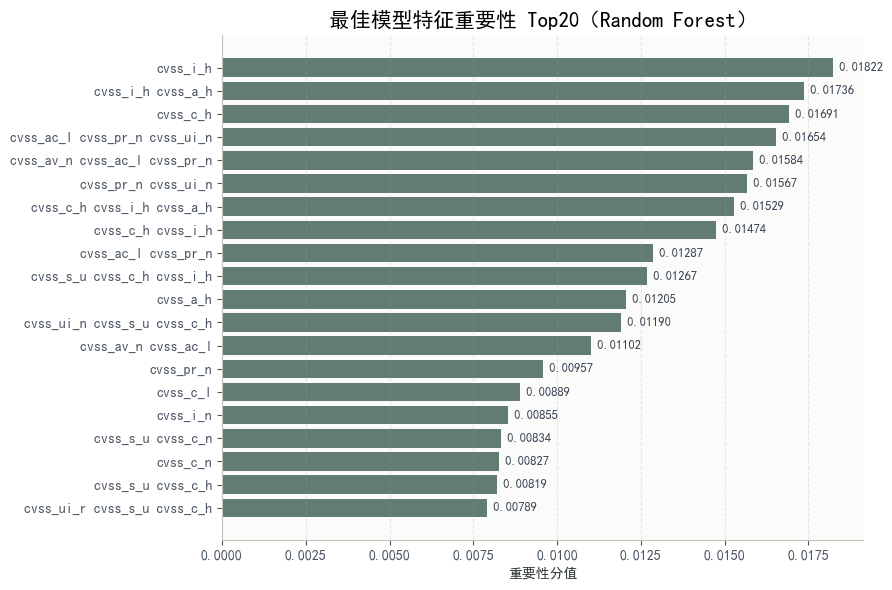

In [23]:
plot_importance_df = importance_df.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    plot_importance_df["feature"],
    plot_importance_df["importance"],
    color="#627b73",
)

ax.set_title(f"最佳模型特征重要性 Top20（{best_model_name}）", fontsize=15)
ax.set_xlabel("重要性分值")
ax.grid(axis="x", linestyle="--", alpha=0.25, color="#9ca3af")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {width:.5f}",
        va="center",
        fontsize=9,
        color="#374151",
    )

plt.tight_layout()
plt.savefig(eval_dir / "feature_importance_top20.svg", format="svg")
plt.show()

## 输出文件

运行完成后，会在 `docs/ml_eval/` 目录生成：

- `model_visualization_metrics.csv`
- `model_visualization_metrics.json`
- `test_accuracy_comparison.svg`
- `test_f1_comparison.svg`
- `cross_validation_mean_comparison.svg`
- `train_test_accuracy_comparison.svg`
- `feature_importance_top20.csv`
- `feature_importance_top20.svg`

如果需要论文正式结果，请把第二个代码单元格中的 `sample_limit = 20000` 改为 `sample_limit = None` 后重新运行。